In [1]:
import os.path as op
import pickle
import copy
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap
from scipy.stats import spearmanr, linregress
from joblib import Parallel, delayed
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.stats.multitest import multipletests
from poisson_glm_granger import compute_granger_causality, permutation_test
from numpy.linalg import norm
import os

In [2]:
np.random.seed(42)

In [3]:
pipeline='NEARICA_behav_v3'
epoch_types=['eye','task']
excluded_subjects=np.array(['C34','C36'])
left_handers=np.array(['C23','C13','C20','C40','C43','C46'])
groups=['typ','dcd']

In [4]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

typ_color=np.array([27,158,119])/255.0
dcd_color=np.array([117,112,179])/255.0

In [5]:
exclude_typ=[]

all_bursts={
    'subject': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'hemi': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,130)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

subjects = pd.read_csv('/home/bonaiuto/dcd_bursts/data/participants.tsv', sep='\t')
df, meta = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')

subject_ids = subjects['participant_id']
for subj_id in subject_ids:
    group=df['Group'][np.where(df['SubjectID']==subj_id)[0]].values[0]
    mab_per=df['MABC_Percentile'][np.where(df['SubjectID']==subj_id)[0]].values[0]        
    if group==0 and mab_per<25:
        exclude_typ.append(subj_id)
        
    if not len(np.where(excluded_subjects==subj_id)[0]):
        subject_data_dir=op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, subj_id, 'processed_data')
        for epoch_type in epoch_types:
            for cluster in ['C3','C4']:
                if cluster=='C3':
                    if np.isin(subj_id,left_handers):
                        hemi='ipsi'
                    else:
                        hemi='contra'
                else:
                    if np.isin(subj_id,left_handers):
                        hemi='contra'
                    else:
                        hemi='ipsi'
                fname=op.join(subject_data_dir, f'bursts_{subj_id}_{epoch_type}_{cluster}.pickle')
                if op.exists(fname):
                    with open(fname,'rb') as file:
                        bursts=pickle.load(file)
                    n_bursts=len(bursts['trial'])
                    bursts['group']=np.array([group for i in range(n_bursts)])
                    bursts['hemi']=np.array([hemi for i in range(n_bursts)])
                    bursts['cluster']=np.array([cluster for i in range(n_bursts)])
                    for key in bursts.keys():
                        if key=='waveform_times':
                            all_bursts[key] = bursts[key]
                        elif key=='waveform':
                            all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
                        else:
                            all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
    else:
        print(f'skipping {subj_id}')

skipping C34
skipping C36


In [6]:
include_typ_idx = ~np.isin(all_bursts['subject'], exclude_typ)
typ_idx=np.where(include_typ_idx & (all_bursts['group']==0))[0]
dcd_idx=np.where(all_bursts['group']==1)[0]

In [7]:
n_typ=len(np.unique(all_bursts['subject'][typ_idx]))
n_dcd=len(np.unique(all_bursts['subject'][dcd_idx]))
print(f'N typical={n_typ}')
print(f'N DCD={n_dcd}')

N typical=24
N DCD=21


In [8]:
burst_times=all_bursts['waveform_times']
pca = PCA(n_components=20)
burst_std=RobustScaler().fit_transform(all_bursts['waveform'])
pca=pca.fit(burst_std[include_typ_idx,:])
pcs = pca.transform(burst_std)

pca_components = pd.DataFrame(pcs)

In [9]:
n_pc_bins=3
region_labels=['ipsi','contra']
unit_labels=[]
for region in region_labels:
    for q in range(n_pc_bins):
        unit_labels.append(f'{region}-{q+1}')

In [10]:
conditions=['exe gross']
events=['E 34']

min_trials=5
step=100/n_pc_bins
pc_idx=5
pc_bins = np.percentile(pca_components[pc_idx], np.arange(0,100+step,step))
    
time_bin_size = .01
time_bins = np.arange(0, 10 + time_bin_size, time_bin_size)

all_binned_bursts={
    'typ': [],
    'dcd': []
}
group_subjs={}
subjects = np.unique(all_bursts['subject'])
for g_idx, group in enumerate(groups):
    group_subj = np.unique(all_bursts['subject'][np.where(all_bursts['group'] == g_idx)[0]])
    group_subjs[group]=[]
    for subject in group_subj:
        if ~np.isin(subject, exclude_typ):
            group_subjs[group].append(subject)
            subj_idx = (all_bursts['subject'] == subject)
            subject_binned_bursts=[]
            for hemi in ['ipsi','contra']:
                region_idx=(all_bursts['hemi'].astype(str)==hemi)
                for q in range(n_pc_bins):
                    q_idx = (pca_components[pc_idx] >= pc_bins[q]) & (pca_components[pc_idx] <= pc_bins[q+1])
                    unit_bursts=[]
                    for condition, event in zip(conditions, events):
                        cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition'] == event)])
                        if len(cond_trials)>=min_trials:
                            for t_idx,trial in enumerate(cond_trials):
                                b_idx = subj_idx & (all_bursts['condition']==event) & region_idx & q_idx & (all_bursts['trial']==trial) & (all_bursts['peak_time']>0) & (all_bursts['peak_time']<=10)
                                binned_bursts, _ = np.histogram(all_bursts['peak_time'][b_idx], bins=time_bins)
                                unit_bursts.append(binned_bursts)
                    
                    subject_binned_bursts.append(unit_bursts)
            subject_binned_bursts=np.array(subject_binned_bursts)
            if subject_binned_bursts.shape[1]>0:
                all_binned_bursts[group].append(subject_binned_bursts)


In [11]:
optimal_lags={
    'typ': [],
    'dcd': [],
}
gc_matrices={
    'typ': [],
    'dcd': [],
}
signed_gc_matrices={
    'typ': [],
    'dcd': [],
}
for group in groups:
    for s_idx in range(len(all_binned_bursts[group])):
        print(f'{group} - {s_idx}')
        X=all_binned_bursts[group][s_idx]
        print(X.shape)

        optimal_lag, gc_matrix, signed_gc_matrix = compute_granger_causality(
            X,
            lags=np.arange(1,10), 
            folds=3,
            n_jobs=20
        )
        
        optimal_lags[group].append(optimal_lag)
        gc_matrices[group].append(gc_matrix)
        signed_gc_matrices[group].append(signed_gc_matrix)


typ - 0
(6, 7, 1000)
Data contains 6 neurons, 7 trials, and 1000 time steps.
typ - 1
(6, 18, 1000)
Data contains 6 neurons, 18 trials, and 1000 time steps.
typ - 2
(6, 20, 1000)
Data contains 6 neurons, 20 trials, and 1000 time steps.
typ - 3
(6, 10, 1000)
Data contains 6 neurons, 10 trials, and 1000 time steps.
typ - 4
(6, 6, 1000)
Data contains 6 neurons, 6 trials, and 1000 time steps.
typ - 5
(6, 16, 1000)
Data contains 6 neurons, 16 trials, and 1000 time steps.
typ - 6
(6, 20, 1000)
Data contains 6 neurons, 20 trials, and 1000 time steps.
typ - 7
(6, 19, 1000)
Data contains 6 neurons, 19 trials, and 1000 time steps.
typ - 8
(6, 19, 1000)
Data contains 6 neurons, 19 trials, and 1000 time steps.
typ - 9
(6, 17, 1000)
Data contains 6 neurons, 17 trials, and 1000 time steps.
typ - 10
(6, 9, 1000)
Data contains 6 neurons, 9 trials, and 1000 time steps.
typ - 11
(6, 11, 1000)
Data contains 6 neurons, 11 trials, and 1000 time steps.
typ - 12
(6, 20, 1000)
Data contains 6 neurons, 20 trial

In [12]:
granger_res_fname='./data/derivatives/NEARICA_behav_v3/granger_results_pc6.npz'

In [13]:
np.savez(
    granger_res_fname,
    optimal_lags=optimal_lags,
    gc_matrices=gc_matrices,
    signed_gc_matrices=signed_gc_matrices
)

In [14]:
loaded_data = np.load(granger_res_fname, allow_pickle=True)
optimal_lags = loaded_data['optimal_lags'].item()
gc_matrices = loaded_data['gc_matrices'].item()
signed_gc_matrices = loaded_data['signed_gc_matrices'].item()

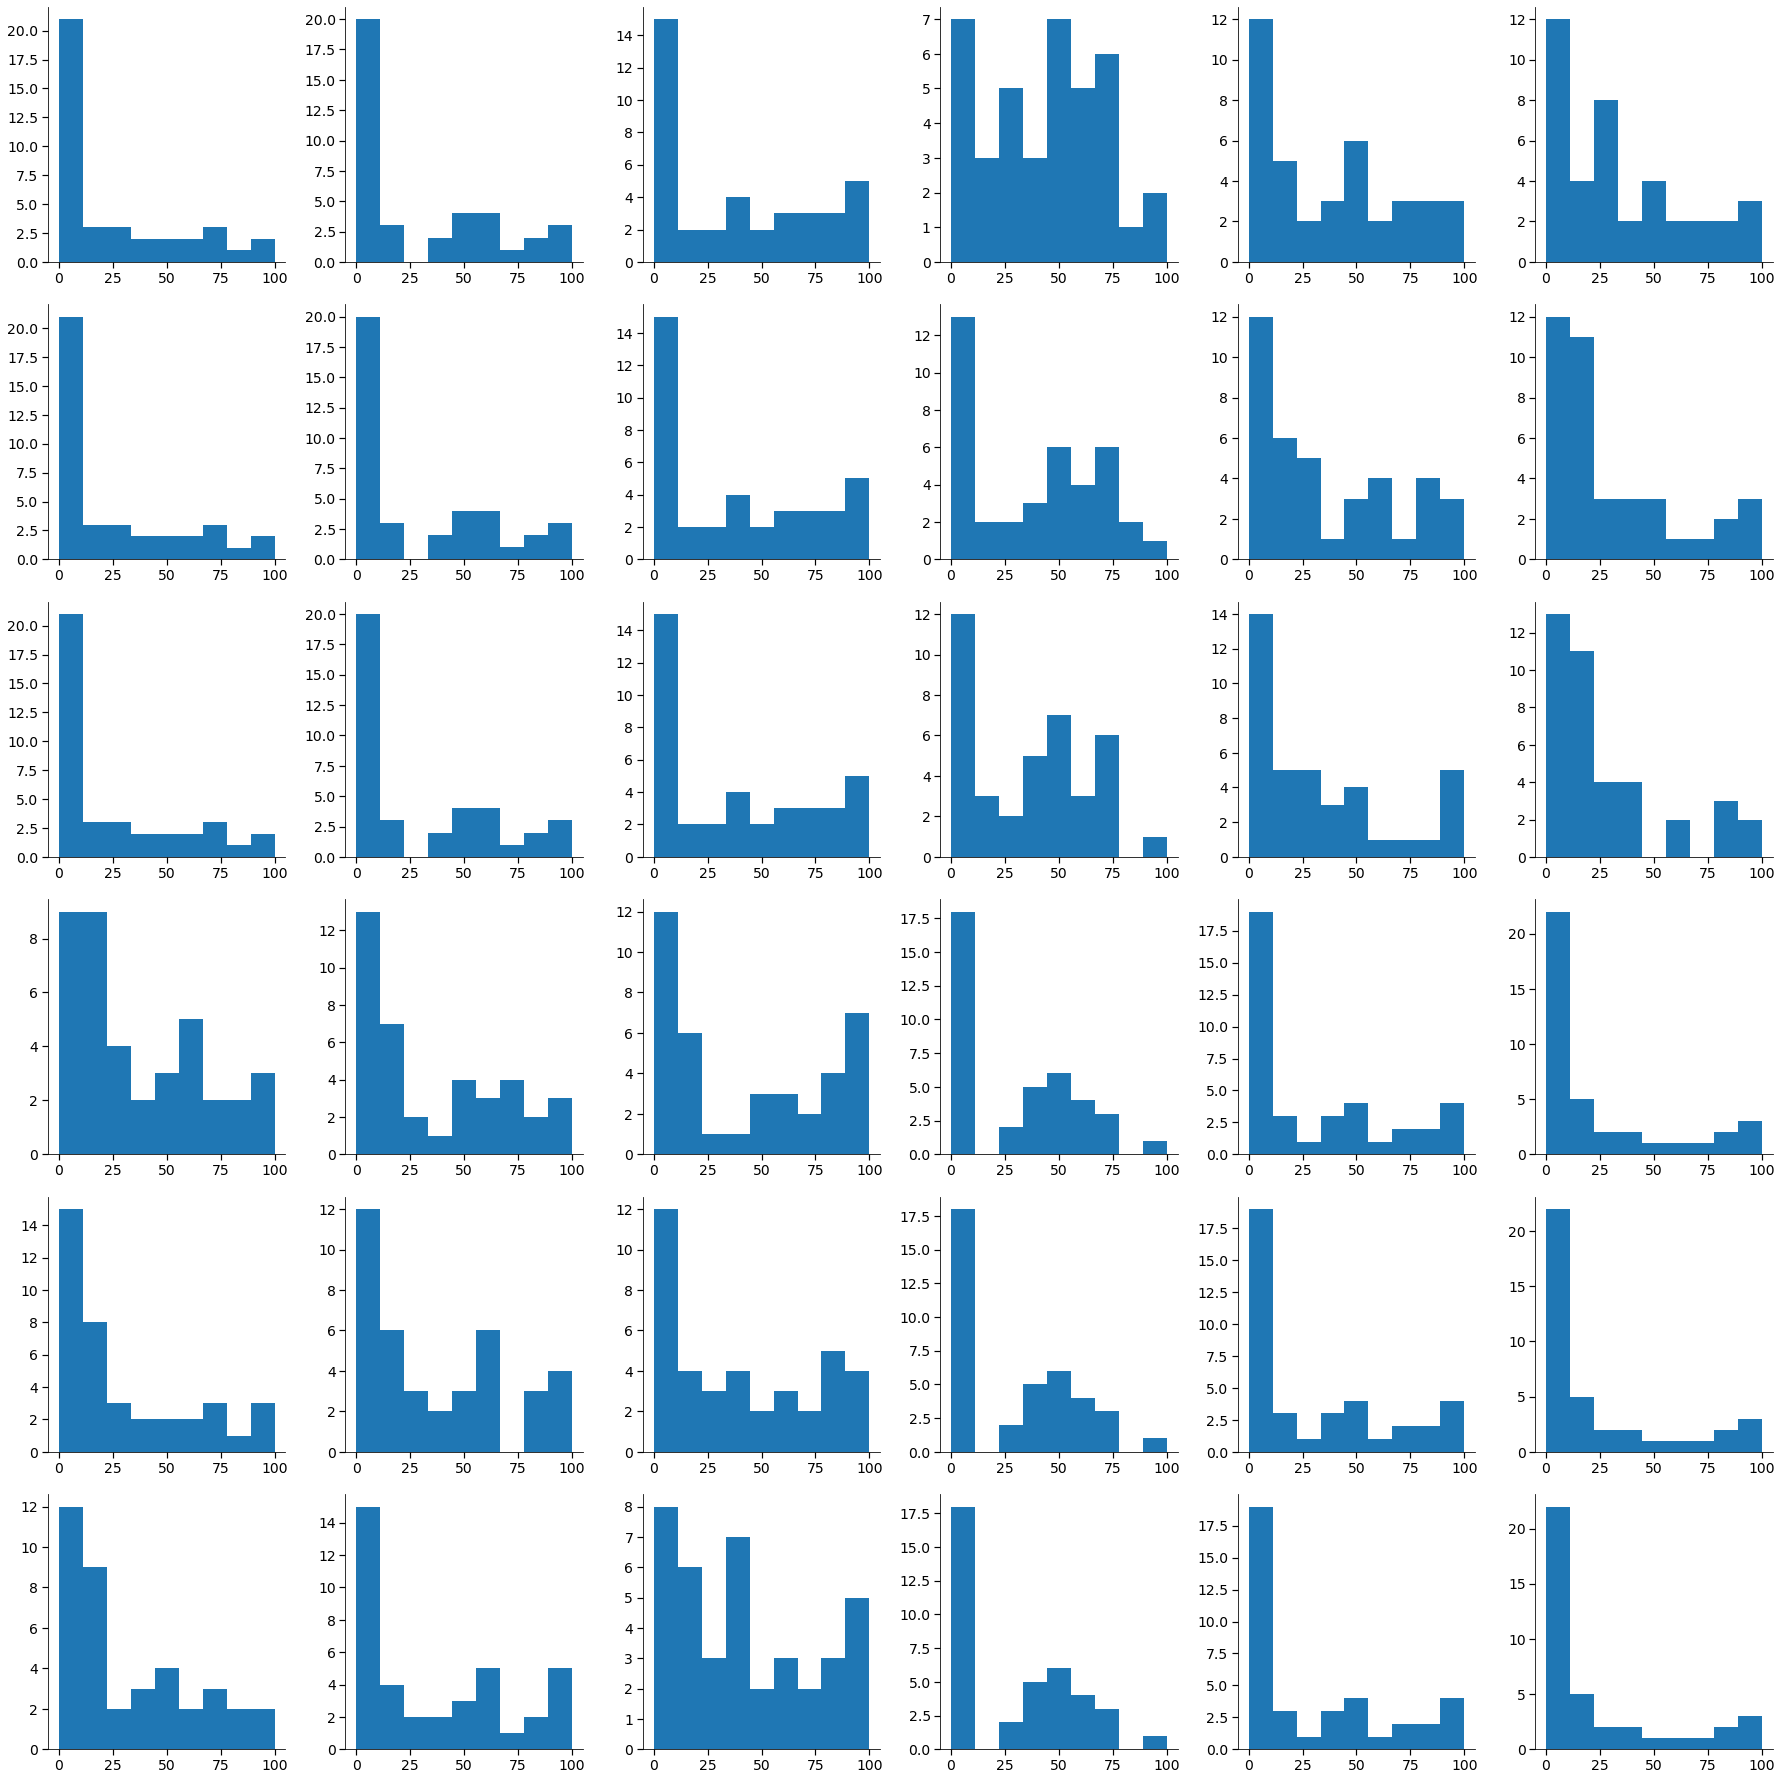

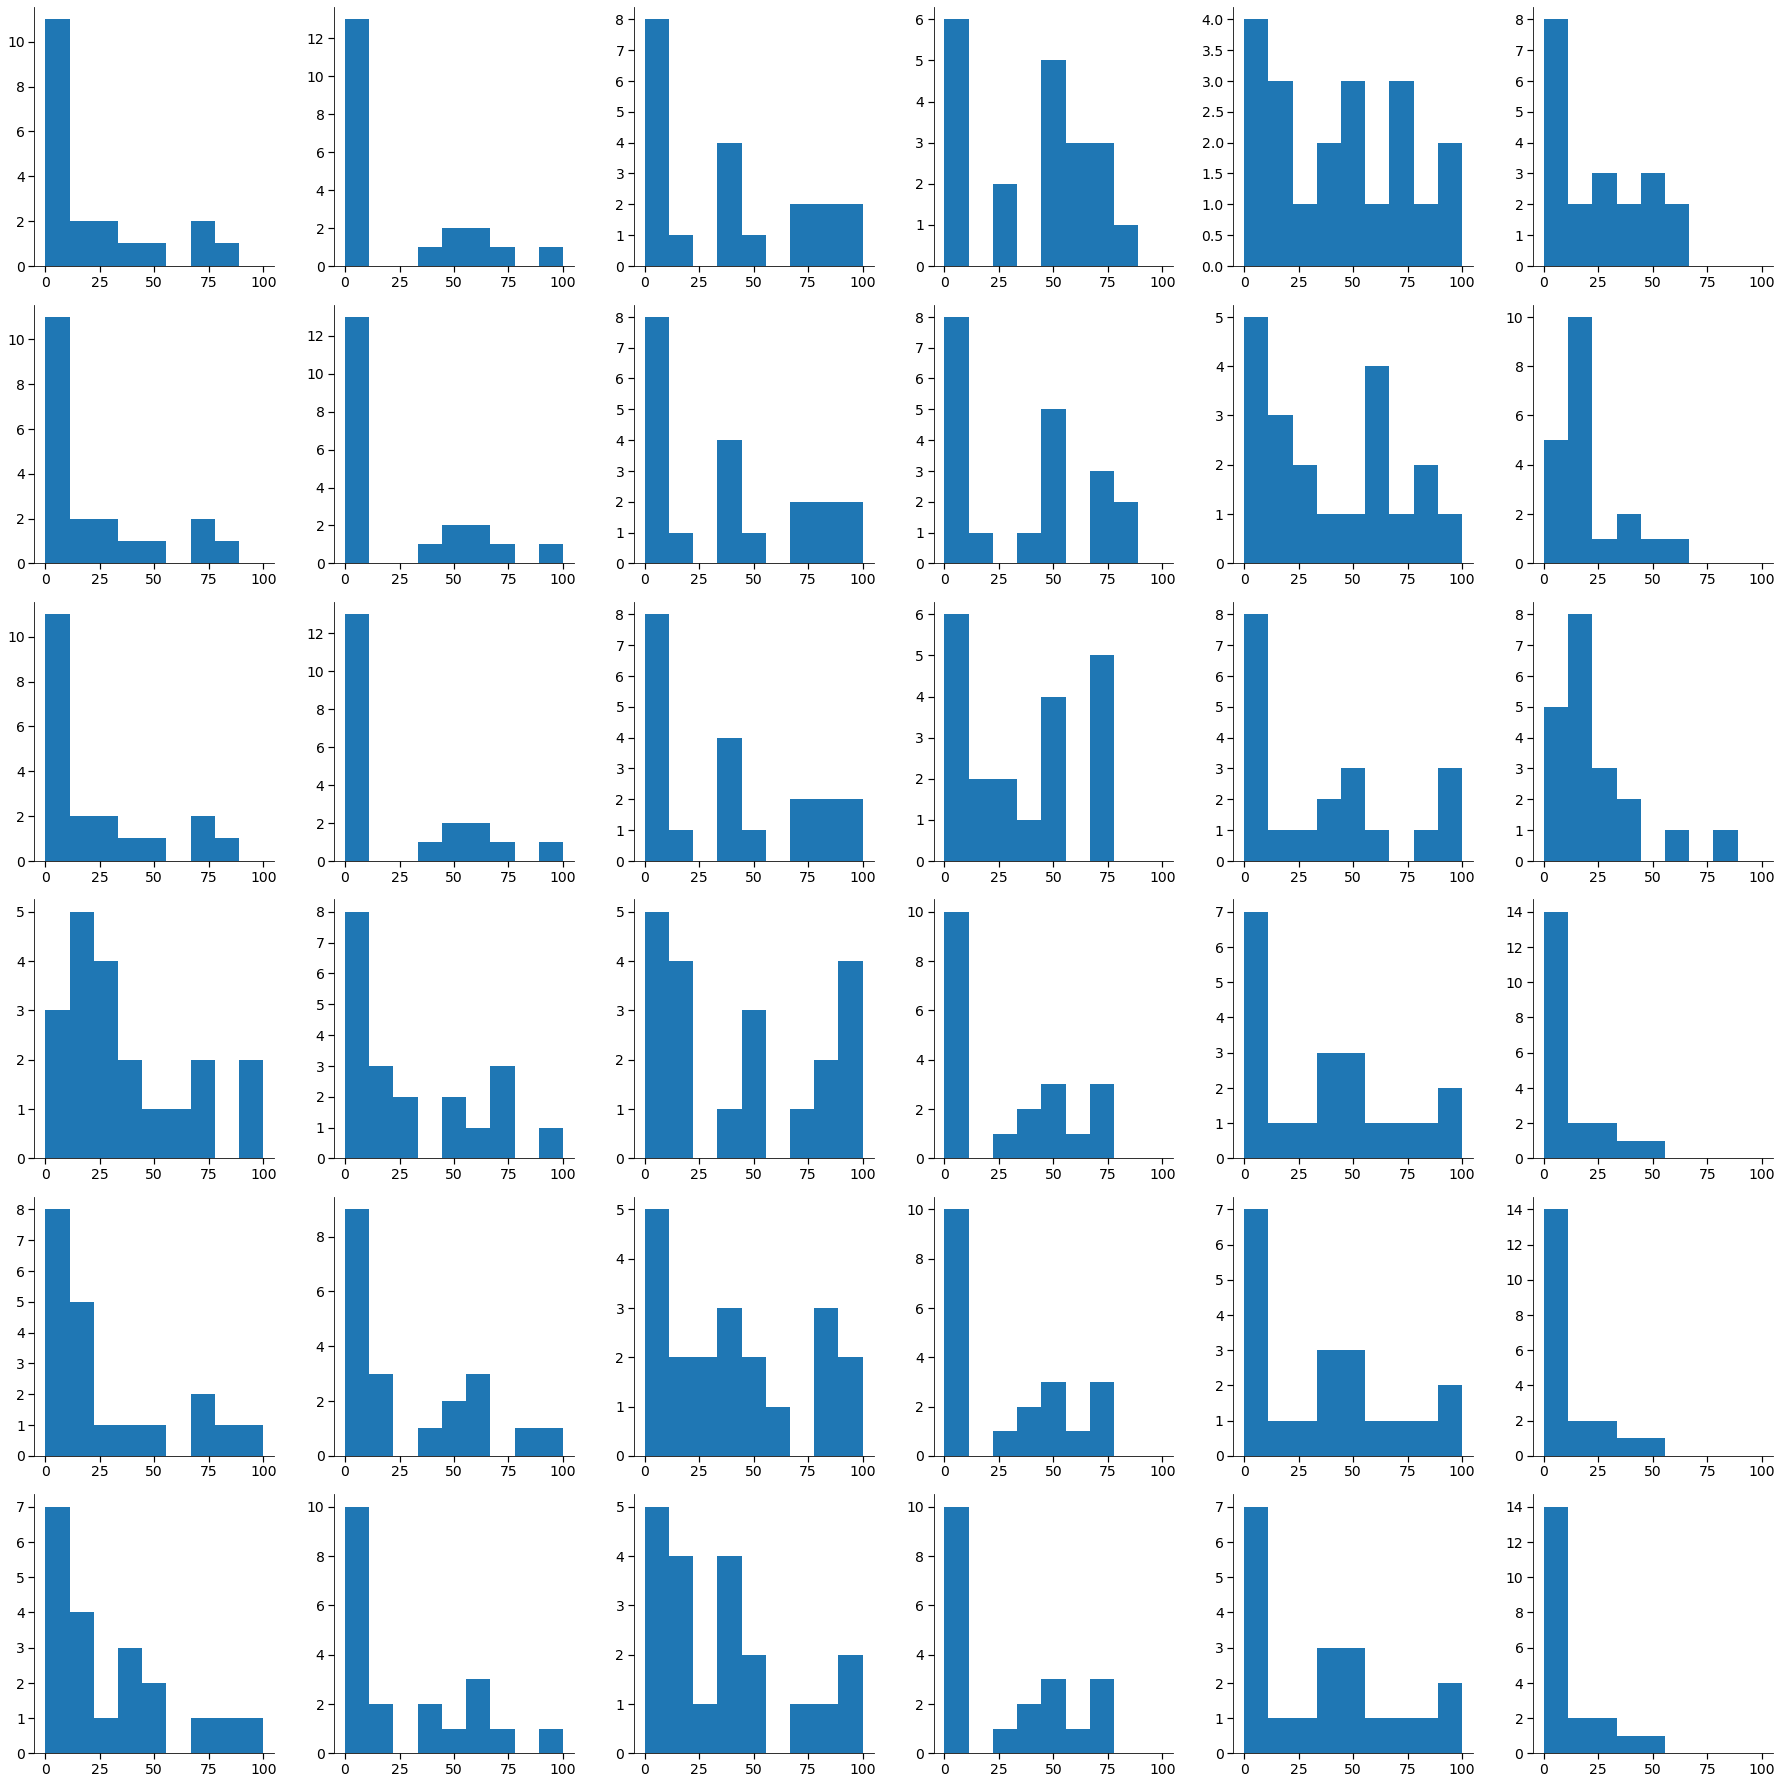

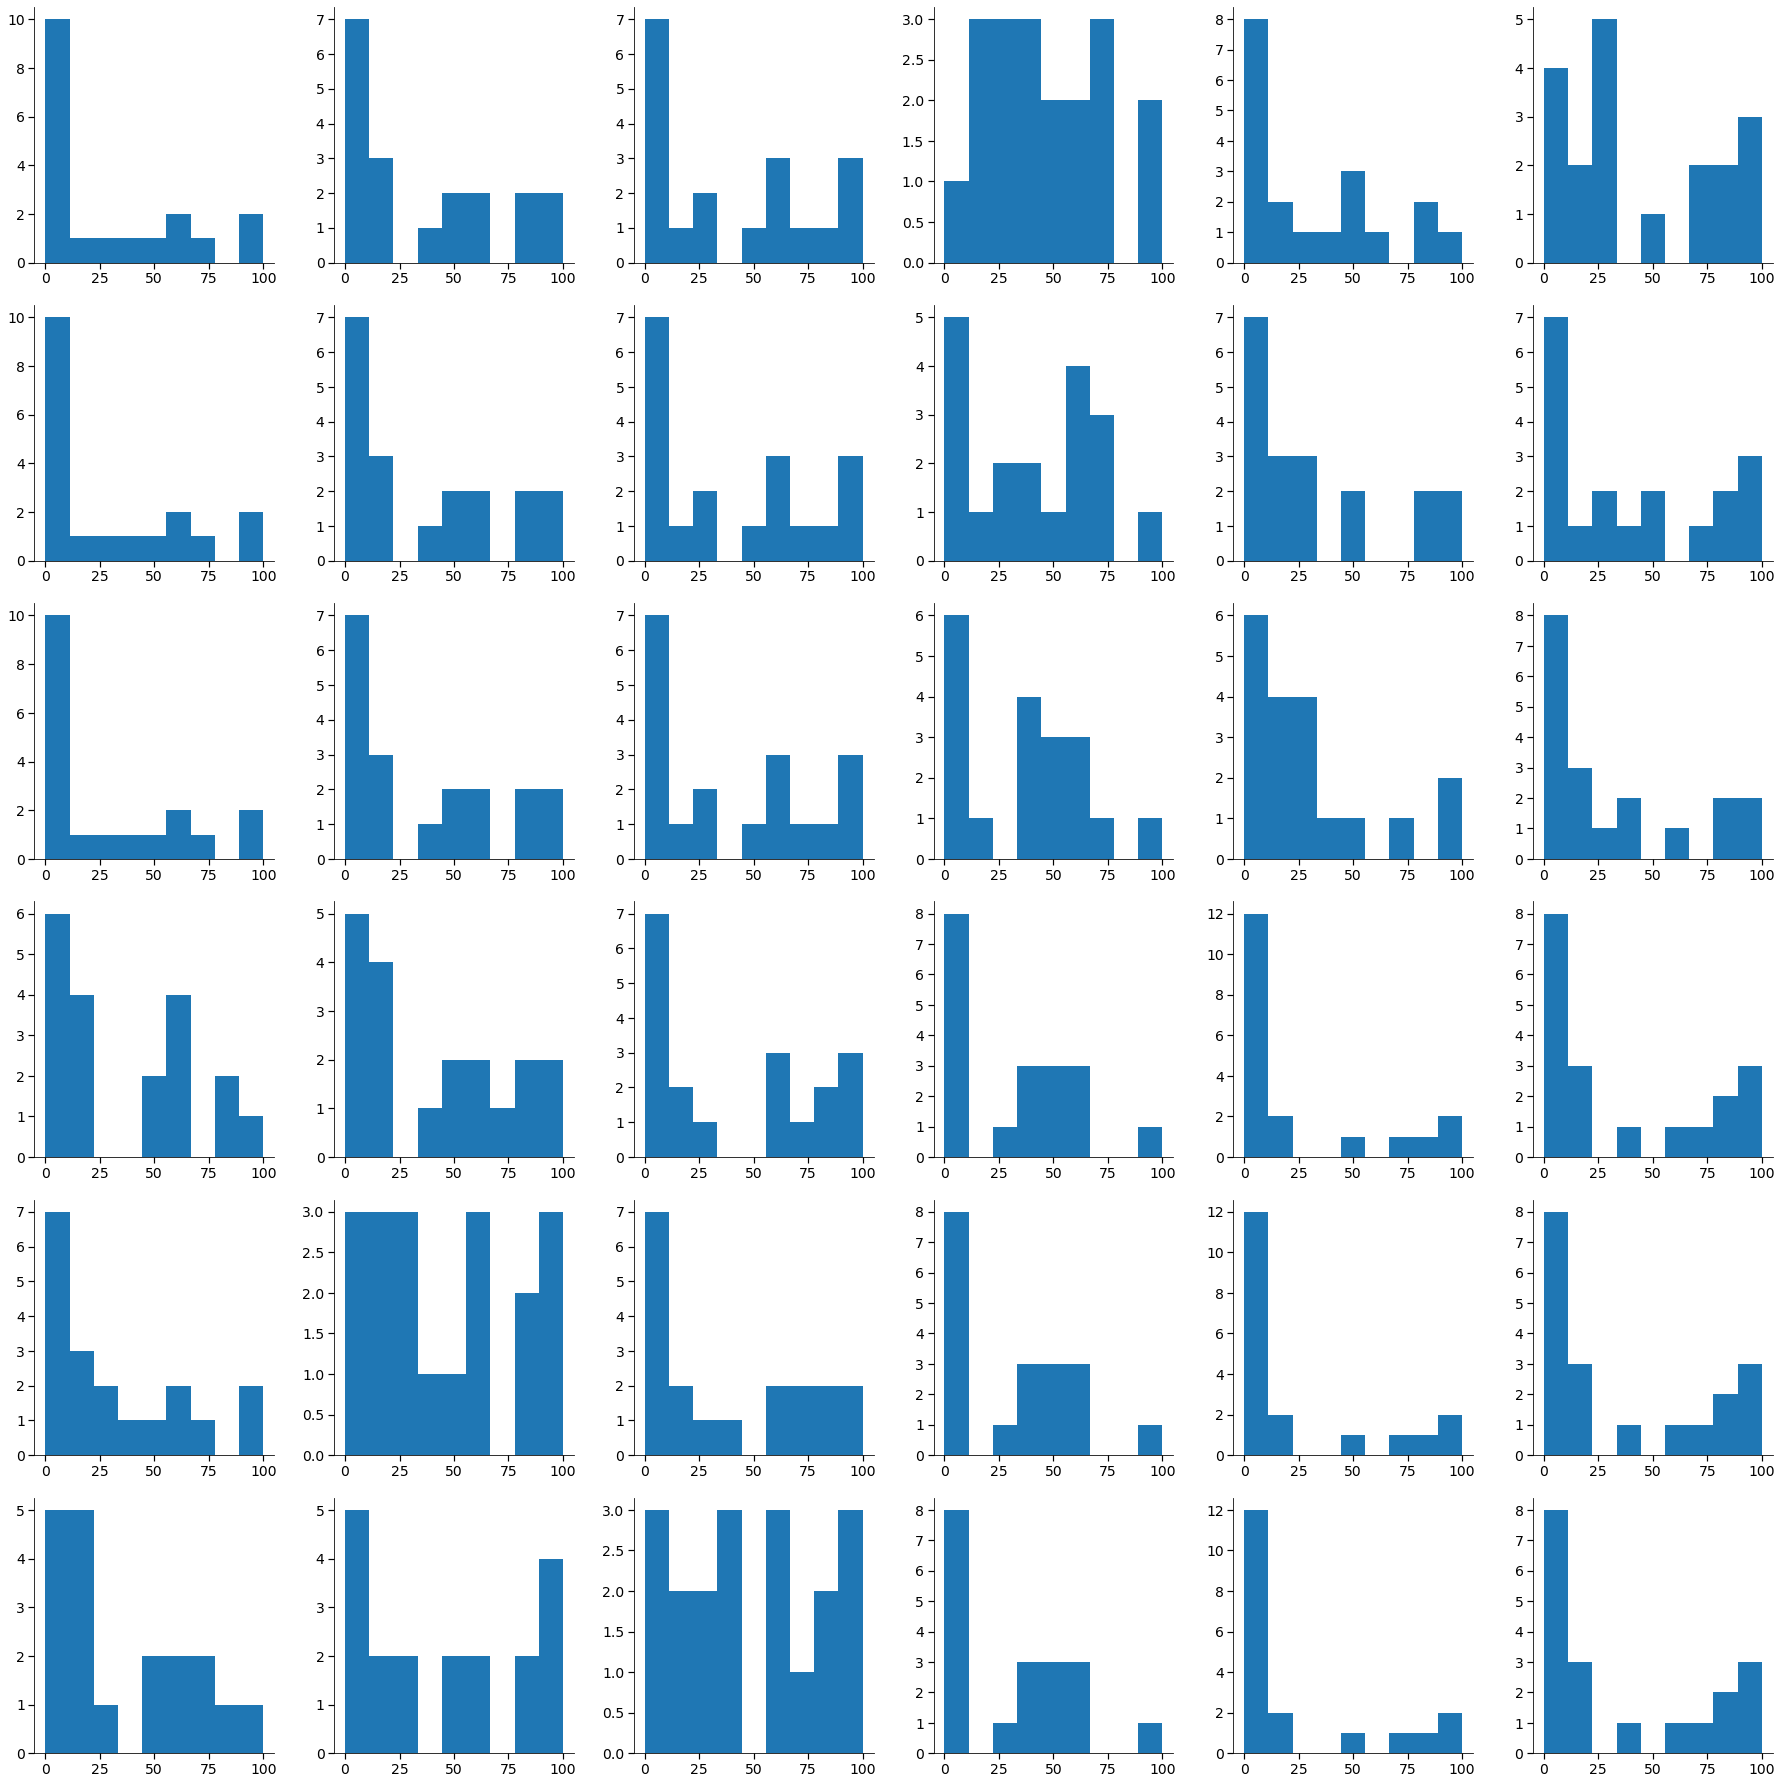

In [15]:
bins=np.linspace(0, 10*time_bin_size*1000,10)
        
fig=plt.figure(figsize=(25,25)) 
gs = GridSpec(len(unit_labels), len(unit_labels))
for source in range(len(unit_labels)):
    for target in range(len(unit_labels)):
        ax = fig.add_subplot(gs[source,target])
        conn_lags=[]
        for group in groups:
            for x in optimal_lags[group]:
                conn_lags.append(x[(source,target)][0]*time_bin_size*1000)
        plt.hist(conn_lags,bins)
        
plt.tight_layout()

fig=plt.figure(figsize=(25,25)) 
gs = GridSpec(len(unit_labels), len(unit_labels))
for source in range(len(unit_labels)):
    for target in range(len(unit_labels)):
        ax = fig.add_subplot(gs[source,target])
        plt.hist([x[(source,target)][0]*time_bin_size*1000 for x in optimal_lags['typ']],bins)
        
plt.tight_layout()

fig=plt.figure(figsize=(25,25)) 
gs = GridSpec(len(unit_labels), len(unit_labels))
for source in range(len(unit_labels)):
    for target in range(len(unit_labels)):
        ax = fig.add_subplot(gs[source,target])
        plt.hist([x[(source,target)][0]*time_bin_size*1000 for x in optimal_lags['dcd']],bins)
        
plt.tight_layout()


In [38]:
n_permutations = 1000
alpha = 0.05
n_units = gc_matrices[groups[0]][0].shape[0]


In [39]:
def shuffle_trials(data):
    """
    Shuffle trials for all neurons in the data array.

    Parameters:
    ----------
    data : ndarray
        The input data array of shape (neurons, trials, time_steps).

    Returns:
    -------
    ndarray
        A shuffled version of the input data with shuffled trials.
    """
    shuffled_data = data.copy()
    neurons, trials, _ = shuffled_data.shape

    for neuron in range(neurons):
        shuffled_data[neuron, :, :] = shuffled_data[neuron, np.random.permutation(trials), :]
    return shuffled_data


def shuffle_time(data):
    """
    Shuffle time points for all neurons in the data array.

    Parameters:
    ----------
    data : ndarray
        The input data array of shape (neurons, trials, time_steps).

    Returns:
    -------
    ndarray
        A shuffled version of the input data with shuffled time points.
    """
    shuffled_data = data.copy()
    neurons, _, time_steps = shuffled_data.shape

    for neuron in range(neurons):
        for trial in range(shuffled_data.shape[1]):
            shuffled_data[neuron, trial, :] = np.random.permutation(shuffled_data[neuron, trial, :])
    return shuffled_data


# Permutation test with separate shuffling for trials and time
permuted_gc_matrices = {group: [] for group in groups}
permuted_signed_gc_matrices = {group: [] for group in groups}

# Run permutations one at a time to avoid large memory usage
for perm_idx in range(n_permutations):
    for group in groups:
        n_group_subjects=len(all_binned_bursts[group])
        permuted_gc_matrix = np.zeros((n_group_subjects, n_units, n_units))
        permuted_signed_gc_matrix = np.zeros((n_group_subjects, n_units, n_units))
        
        for s_idx in range(n_group_subjects):
            subject_data=all_binned_bursts[group][s_idx]
            print(f'Permutation {perm_idx}, Group {group}, Subject {s_idx}')

            # Shuffle trials for off-diagonal elements
            shuffled_trials_X = shuffle_trials(subject_data)
            _, gc_trials, signed_gc_trials = compute_granger_causality(
                shuffled_trials_X,
                n_jobs=-1,
                pairwise_lags=optimal_lags[group][s_idx]
            )
            # Shuffle time for diagonal elements
            shuffled_time_X = shuffle_time(subject_data)
            _, gc_time, signed_gc_time = compute_granger_causality(
                shuffled_time_X,
                n_jobs=-1,
                pairwise_lags=optimal_lags[group][s_idx]
            )
            
            # Combine results: diagonal from time shuffling, off-diagonal from trial shuffling
            for i in range(n_units):
                for j in range(n_units):
                    if i == j:
                        permuted_gc_matrix[s_idx, i, j] = gc_time[i, j]
                        permuted_signed_gc_matrix[s_idx, i, j] = signed_gc_time[i, j]
                    else:
                        permuted_gc_matrix[s_idx, i, j] = gc_trials[i, j]
                        permuted_signed_gc_matrix[s_idx, i, j] = signed_gc_trials[i, j]

        # Average across subjects
        permuted_gc_matrices[group].append(np.mean(permuted_gc_matrix, axis=0))
        permuted_signed_gc_matrices[group].append(np.mean(permuted_signed_gc_matrix, axis=0))


Permutation 0, Group typ, Subject 0
Data contains 6 neurons, 7 trials, and 1000 time steps.
Data contains 6 neurons, 7 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 1
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 2
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 3
Data contains 6 neurons, 10 trials, and 1000 time steps.
Data contains 6 neurons, 10 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 4
Data contains 6 neurons, 6 trials, and 1000 time steps.
Data contains 6 neurons, 6 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 5
Data contains 6 neurons, 16 trials, and 1000 time steps.
Data contains 6 neurons, 16 trials, and 1000 time steps.
Permutation 0, Group typ, Subject 6
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contai

Permutation 1, Group typ, Subject 16
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 1, Group typ, Subject 17
Data contains 6 neurons, 16 trials, and 1000 time steps.
Data contains 6 neurons, 16 trials, and 1000 time steps.
Permutation 1, Group typ, Subject 18
Data contains 6 neurons, 7 trials, and 1000 time steps.
Data contains 6 neurons, 7 trials, and 1000 time steps.
Permutation 1, Group typ, Subject 19
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 1, Group dcd, Subject 0
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 1, Group dcd, Subject 1
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 1, Group dcd, Subject 2
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data 

Permutation 2, Group dcd, Subject 12
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 13
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 14
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 15
Data contains 6 neurons, 16 trials, and 1000 time steps.
Data contains 6 neurons, 16 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 16
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 17
Data contains 6 neurons, 15 trials, and 1000 time steps.
Data contains 6 neurons, 15 trials, and 1000 time steps.
Permutation 2, Group dcd, Subject 18
Data contains 6 neurons, 17 trials, and 1000 time steps.


Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 9
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 10
Data contains 6 neurons, 9 trials, and 1000 time steps.
Data contains 6 neurons, 9 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 11
Data contains 6 neurons, 11 trials, and 1000 time steps.
Data contains 6 neurons, 11 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 12
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 13
Data contains 6 neurons, 6 trials, and 1000 time steps.
Data contains 6 neurons, 6 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 14
Data contains 6 neurons, 15 trials, and 1000 time steps.
Data contains 6 neurons, 15 trials, and 1000 time steps.
Permutation 4, Group typ, Subject 15
Data 

Data contains 6 neurons, 8 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 6
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 7
Data contains 6 neurons, 5 trials, and 1000 time steps.
Data contains 6 neurons, 5 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 8
Data contains 6 neurons, 15 trials, and 1000 time steps.
Data contains 6 neurons, 15 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 9
Data contains 6 neurons, 8 trials, and 1000 time steps.
Data contains 6 neurons, 8 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 10
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 11
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 5, Group dcd, Subject 12
Data cont

...

Data contains 6 neurons, 15 trials, and 1000 time steps.
Permutation 32, Group typ, Subject 15
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 32, Group typ, Subject 16
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 32, Group typ, Subject 17
Data contains 6 neurons, 16 trials, and 1000 time steps.
Data contains 6 neurons, 16 trials, and 1000 time steps.
Permutation 32, Group typ, Subject 18
Data contains 6 neurons, 7 trials, and 1000 time steps.
Data contains 6 neurons, 7 trials, and 1000 time steps.
Permutation 32, Group typ, Subject 19
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 32, Group dcd, Subject 0
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 32, Group dcd, Subject

Permutation 33, Group dcd, Subject 10
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 11
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 12
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 13
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 14
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 15
Data contains 6 neurons, 16 trials, and 1000 time steps.
Data contains 6 neurons, 16 trials, and 1000 time steps.
Permutation 33, Group dcd, Subject 16
Data contains 6 neurons, 18 trials, and 1000 time 

Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 7
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 8
Data contains 6 neurons, 19 trials, and 1000 time steps.
Data contains 6 neurons, 19 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 9
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 10
Data contains 6 neurons, 9 trials, and 1000 time steps.
Data contains 6 neurons, 9 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 11
Data contains 6 neurons, 11 trials, and 1000 time steps.
Data contains 6 neurons, 11 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 12
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 35, Group typ, Subject 1

Permutation 36, Group dcd, Subject 2
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 3
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 4
Data contains 6 neurons, 5 trials, and 1000 time steps.
Data contains 6 neurons, 5 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 5
Data contains 6 neurons, 8 trials, and 1000 time steps.
Data contains 6 neurons, 8 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 6
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 7
Data contains 6 neurons, 5 trials, and 1000 time steps.
Data contains 6 neurons, 5 trials, and 1000 time steps.
Permutation 36, Group dcd, Subject 8
Data contains 6 neurons, 15 trials, and 1000 time steps.
Data c

Data contains 6 neurons, 15 trials, and 1000 time steps.
Permutation 37, Group dcd, Subject 18
Data contains 6 neurons, 17 trials, and 1000 time steps.
Data contains 6 neurons, 17 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 0
Data contains 6 neurons, 7 trials, and 1000 time steps.
Data contains 6 neurons, 7 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 1
Data contains 6 neurons, 18 trials, and 1000 time steps.
Data contains 6 neurons, 18 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 2
Data contains 6 neurons, 20 trials, and 1000 time steps.
Data contains 6 neurons, 20 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 3
Data contains 6 neurons, 10 trials, and 1000 time steps.
Data contains 6 neurons, 10 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 4
Data contains 6 neurons, 6 trials, and 1000 time steps.
Data contains 6 neurons, 6 trials, and 1000 time steps.
Permutation 38, Group typ, Subject 5
Dat

In [40]:
shuffle_one_samp_res_fname='./data/derivatives/NEARICA_behav_v3/granger_shuffled_one_samp_results_pc6.npz'

In [41]:
np.savez(
    shuffle_one_samp_res_fname,
    permuted_gc_matrices=permuted_gc_matrices,
    permuted_signed_gc_matrices=permuted_signed_gc_matrices
)

In [42]:
loaded_data = np.load(shuffle_one_samp_res_fname, allow_pickle=True)
permuted_gc_matrices = loaded_data['permuted_gc_matrices'].item()
permuted_signed_gc_matrices = loaded_data['permuted_signed_gc_matrices'].item()

In [43]:
n_permutations=len(permuted_gc_matrices['typ'])

In [44]:
n_permutations

1000

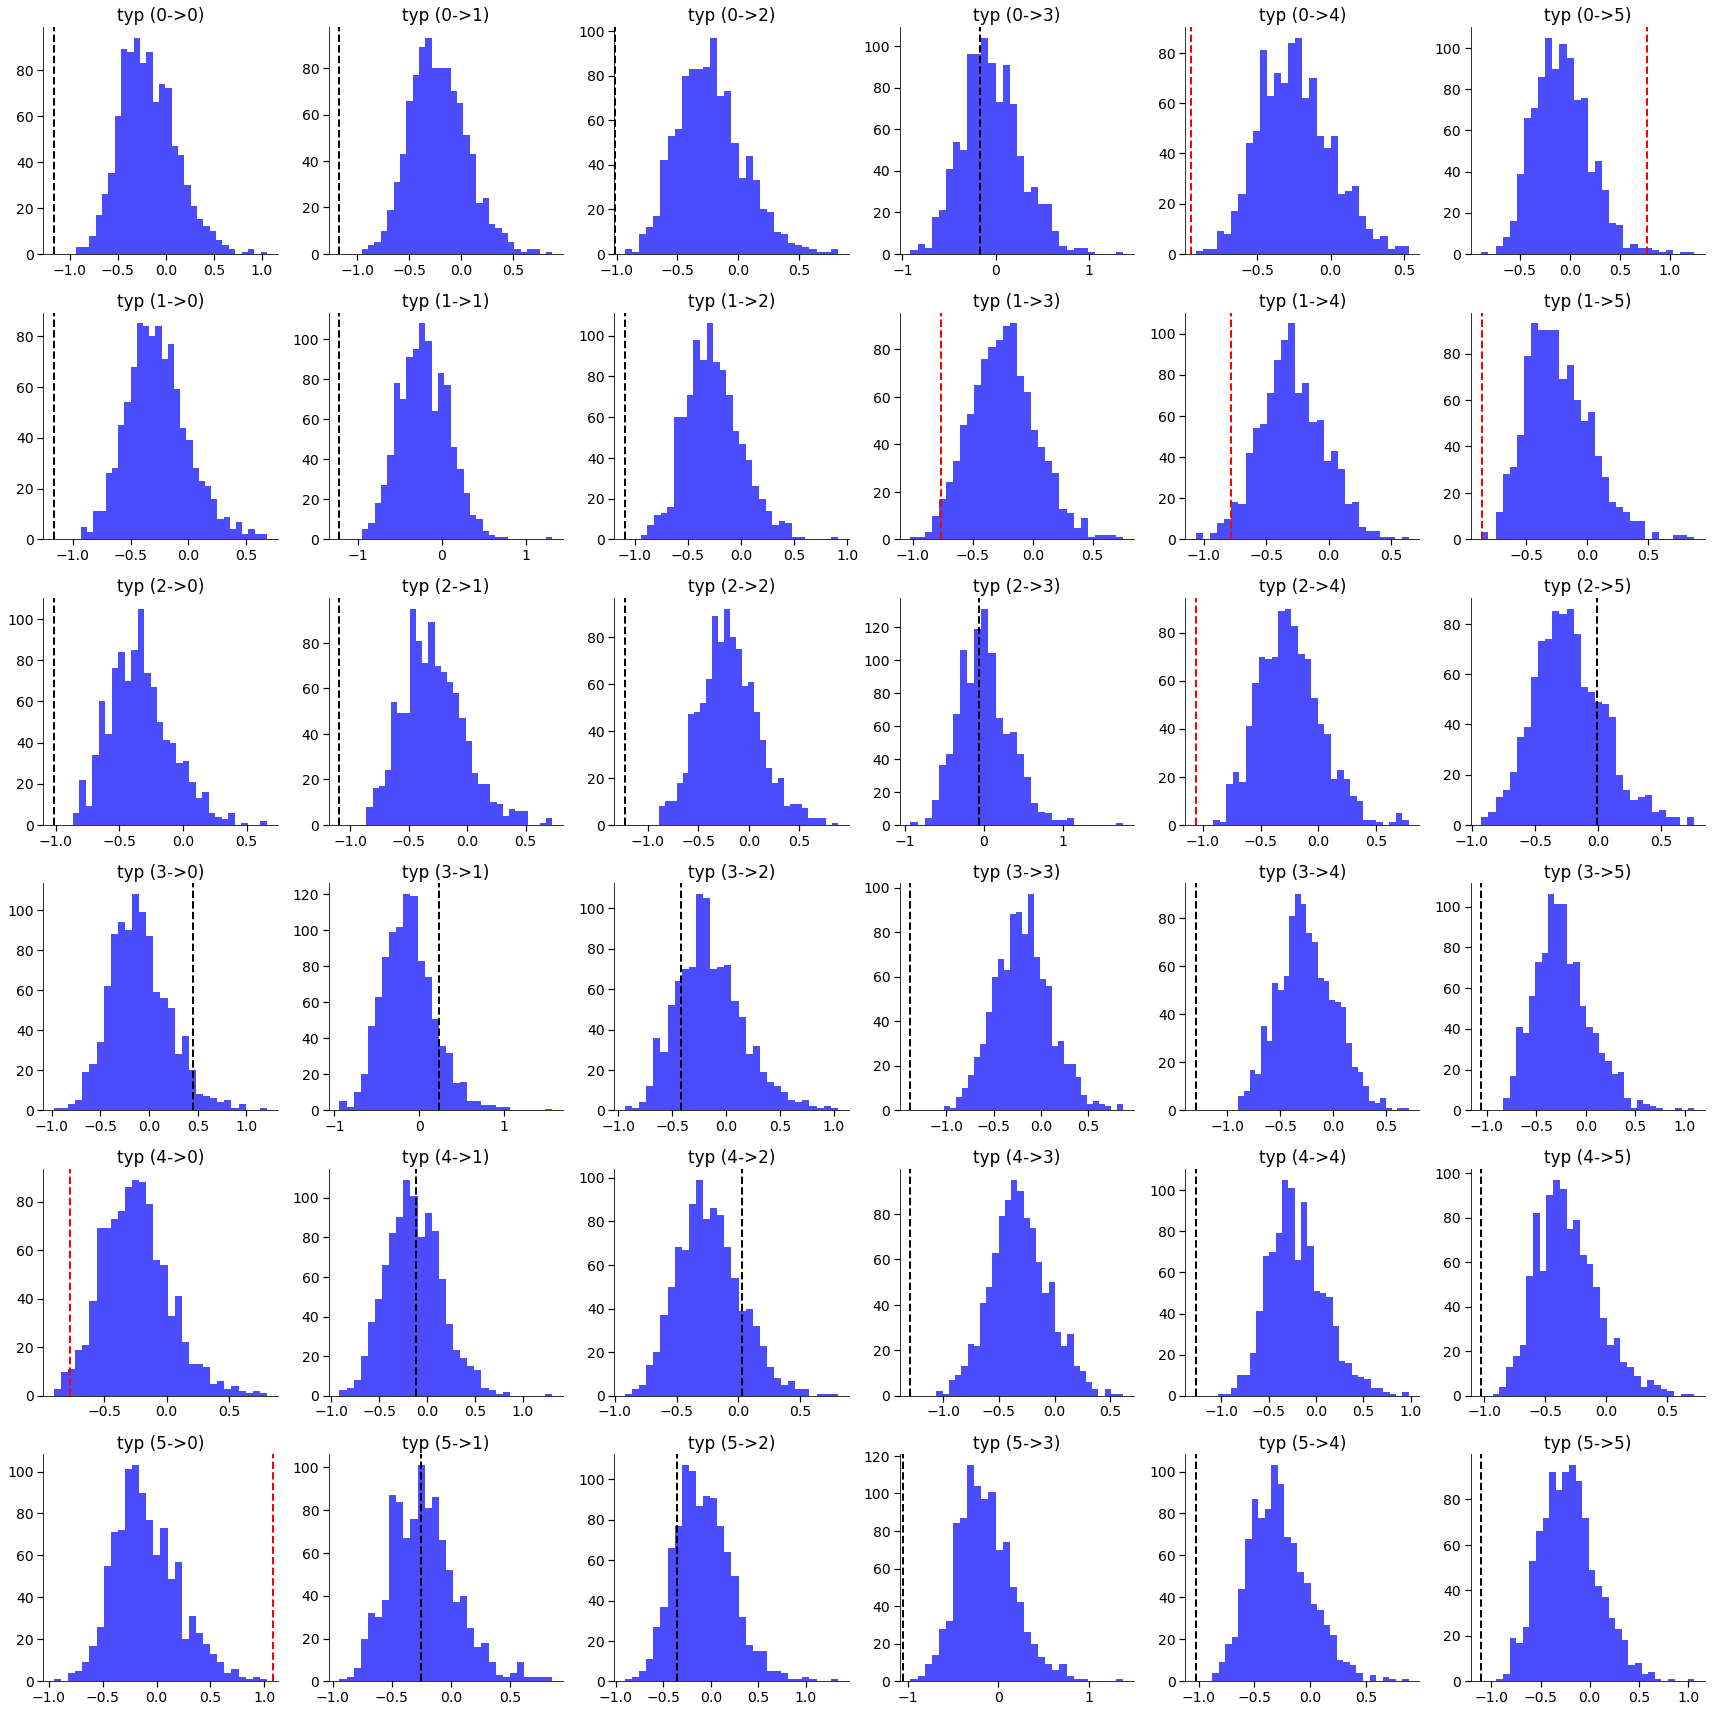

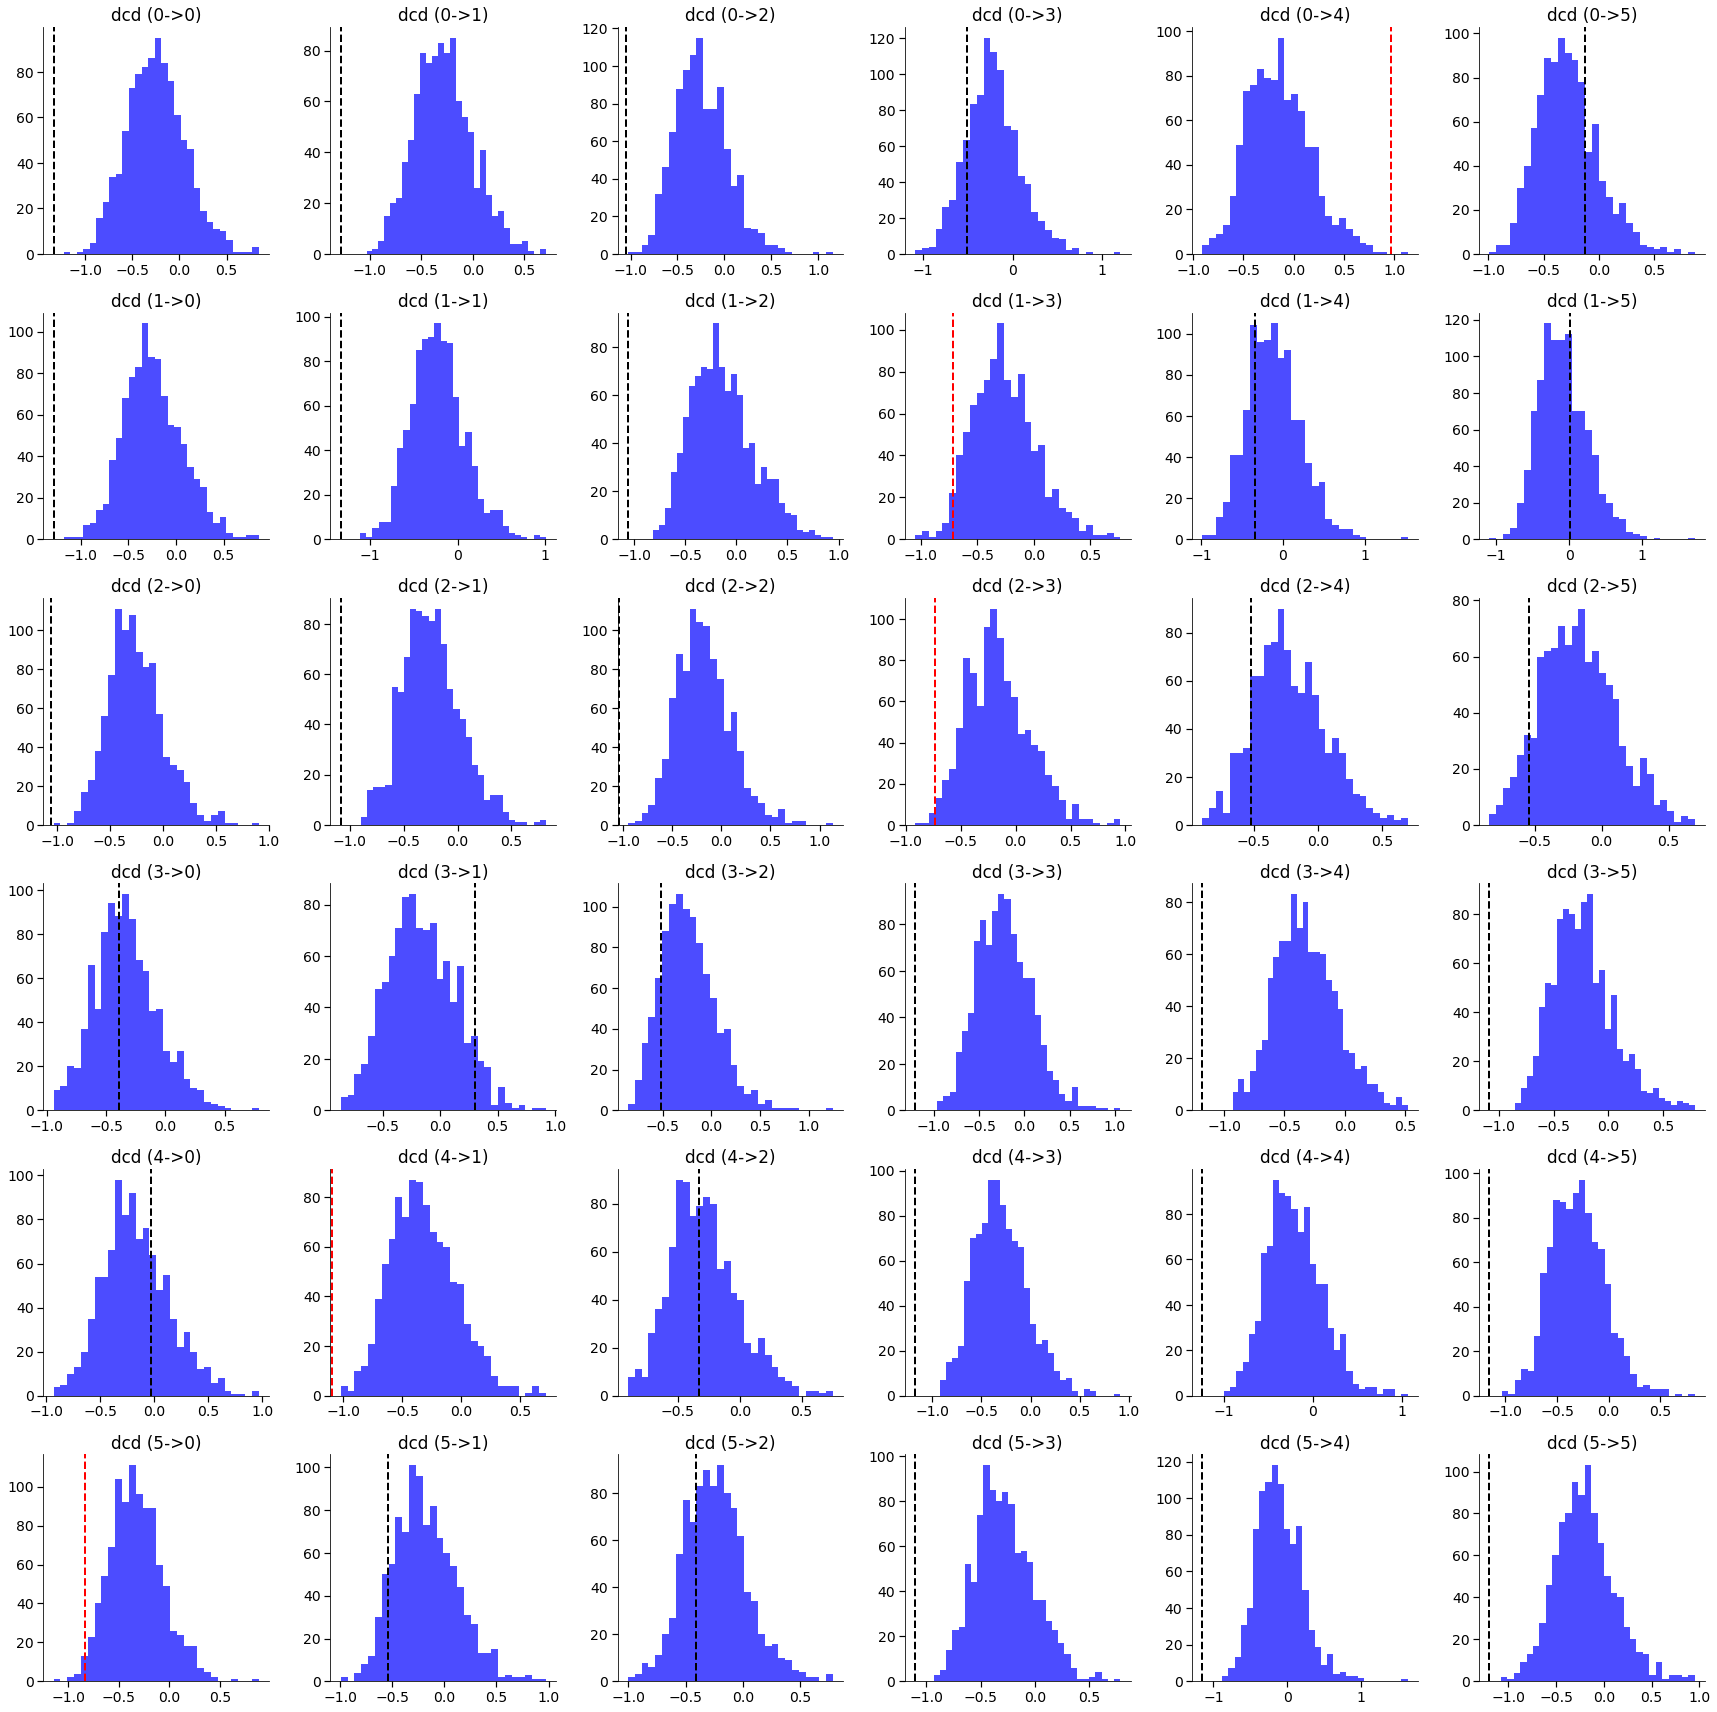

In [45]:
region_map = ['-'.join(label.split('-')[:-1]) for label in unit_labels]

# Initialize dictionaries to store corrected p-values
one_samp_p_values = {group: np.zeros((n_units, n_units)) for group in groups}

# Compute p-values for each matrix in each condition
for g_idx, group in enumerate(groups):
    observed_gc_matrix = np.mean(signed_gc_matrices[group], axis=0)  # Average across subjects
    permuted_gc_array = np.array(permuted_signed_gc_matrices[group])  # Convert to numpy array (shape: n_permutations x neurons x neurons)

    fig = plt.figure(figsize=(24, 24))
    gs = GridSpec(n_units, n_units)

    # Collect inter-regional p-values for FDR
    region_indices = []
    p_values_flat = []

    for i in range(n_units):
        for j in range(n_units):
            observed_value = observed_gc_matrix[i, j]
            null_distribution = permuted_gc_array[:, i, j]
            
            p_value = (np.sum(np.abs(null_distribution) >= np.abs(observed_value)) + 1) / (n_permutations + 1)
            region_indices.append((i, j))
            p_values_flat.append(p_value)
            
    # Apply FDR correction to inter-regional p-values only
    _, corrected_p_values_flat, _, _ = multipletests(p_values_flat, alpha=0.05, method='fdr_bh')

    # Fill corrected p-value matrix
    for (i, j), p_corr in zip(region_indices, corrected_p_values_flat):
        one_samp_p_values[group][i, j] = p_corr
        
    for i in range(n_units):
        for j in range(n_units):
            if region_map[i]==region_map[j]:
                one_samp_p_values[group][i,j]=1

    # Update plots based on corrected p-values
    for i in range(n_units):
        for j in range(n_units):
            observed_value = observed_gc_matrix[i, j]
            null_distribution = permuted_gc_array[:, i, j]
            ax = fig.add_subplot(gs[i, j])
            # Plot histogram of null distribution with observed value
            plt.hist(null_distribution, bins=30, alpha=0.7, color='blue', label='Permuted GC')
            plt.title(f"{group} ({i}->{j})")
            col = 'black'
            if one_samp_p_values[group][i, j] < 0.05:
                col = 'red'
            plt.axvline(x=observed_gc_matrix[i, j], color=col, linestyle='dashed', linewidth=2)
    
    plt.tight_layout()


In [46]:
# Store observed differences
n_typ = len(signed_gc_matrices['typ'])  # Number of subjects in 'typ'
n_dcd = len(signed_gc_matrices['dcd'])  # Number of subjects in 'dcd'

# Compute observed differences (mean difference between groups)
mean_typ = np.mean(signed_gc_matrices['typ'], axis=0)  # Mean across 'typ' subjects
mean_dcd = np.mean(signed_gc_matrices['dcd'], axis=0)  # Mean across 'dcd' subjects
observed_diff_gc = mean_dcd - mean_typ  # Shape: (neurons, neurons)

# Pool all data for permutation testing
all_data = np.vstack([signed_gc_matrices['typ'], signed_gc_matrices['dcd']])
n_total = n_typ + n_dcd

# Permutation testing
n_group_permutations = 10000
permuted_diff_gc_matrices = np.zeros((n_group_permutations, n_units, n_units))

for perm_idx in range(n_group_permutations):
    print(f'Permutation {perm_idx}')
    
    # Shuffle subject labels
    perm_indices = np.random.permutation(n_total)
    perm_typ = all_data[perm_indices[:n_typ]]  # Random subset as 'typ'
    perm_dcd = all_data[perm_indices[n_typ:]]  # Random subset as 'dcd'
    
    # Compute permuted mean differences
    perm_mean_typ = np.mean(perm_typ, axis=0)
    perm_mean_dcd = np.mean(perm_dcd, axis=0)
    permuted_diff_gc_matrices[perm_idx] = perm_mean_dcd - perm_mean_typ

# Compute p-values
p_values_diff = np.zeros((n_units, n_units))

for i in range(n_units):
    for j in range(n_units):
        observed_value = observed_diff_gc[i, j]
        null_distribution = permuted_diff_gc_matrices[:, i, j]
        
        # Compute two-tailed p-value
        p_values_diff[i, j] = (np.sum(np.abs(null_distribution) >= np.abs(observed_value)) + 1) / (n_group_permutations + 1)


Permutation 0
Permutation 1
Permutation 2
Permutation 3
Permutation 4
Permutation 5
Permutation 6
Permutation 7
Permutation 8
Permutation 9
Permutation 10
Permutation 11
Permutation 12
Permutation 13
Permutation 14
Permutation 15
Permutation 16
Permutation 17
Permutation 18
Permutation 19
Permutation 20
Permutation 21
Permutation 22
Permutation 23
Permutation 24
Permutation 25
Permutation 26
Permutation 27
Permutation 28
Permutation 29
Permutation 30
Permutation 31
Permutation 32
Permutation 33
Permutation 34
Permutation 35
Permutation 36
Permutation 37
Permutation 38
Permutation 39
Permutation 40
Permutation 41
Permutation 42
Permutation 43
Permutation 44
Permutation 45
Permutation 46
Permutation 47
Permutation 48
Permutation 49
Permutation 50
Permutation 51
Permutation 52
Permutation 53
Permutation 54
Permutation 55
Permutation 56
Permutation 57
Permutation 58
Permutation 59
Permutation 60
Permutation 61
Permutation 62
Permutation 63
Permutation 64
Permutation 65
Permutation 66
Permu

Permutation 2139
Permutation 2140
Permutation 2141
Permutation 2142
Permutation 2143
Permutation 2144
Permutation 2145
Permutation 2146
Permutation 2147
Permutation 2148
Permutation 2149
Permutation 2150
Permutation 2151
Permutation 2152
Permutation 2153
Permutation 2154
Permutation 2155
Permutation 2156
Permutation 2157
Permutation 2158
Permutation 2159
Permutation 2160
Permutation 2161
Permutation 2162
Permutation 2163
Permutation 2164
Permutation 2165
Permutation 2166
Permutation 2167
Permutation 2168
Permutation 2169
Permutation 2170
Permutation 2171
Permutation 2172
Permutation 2173
Permutation 2174
Permutation 2175
Permutation 2176
Permutation 2177
Permutation 2178
Permutation 2179
Permutation 2180
Permutation 2181
Permutation 2182
Permutation 2183
Permutation 2184
Permutation 2185
Permutation 2186
Permutation 2187
Permutation 2188
Permutation 2189
Permutation 2190
Permutation 2191
Permutation 2192
Permutation 2193
Permutation 2194
Permutation 2195
Permutation 2196
Permutation 21

Permutation 3535
Permutation 3536
Permutation 3537
Permutation 3538
Permutation 3539
Permutation 3540
Permutation 3541
Permutation 3542
Permutation 3543
Permutation 3544
Permutation 3545
Permutation 3546
Permutation 3547
Permutation 3548
Permutation 3549
Permutation 3550
Permutation 3551
Permutation 3552
Permutation 3553
Permutation 3554
Permutation 3555
Permutation 3556
Permutation 3557
Permutation 3558
Permutation 3559
Permutation 3560
Permutation 3561
Permutation 3562
Permutation 3563
Permutation 3564
Permutation 3565
Permutation 3566
Permutation 3567
Permutation 3568
Permutation 3569
Permutation 3570
Permutation 3571
Permutation 3572
Permutation 3573
Permutation 3574
Permutation 3575
Permutation 3576
Permutation 3577
Permutation 3578
Permutation 3579
Permutation 3580
Permutation 3581
Permutation 3582
Permutation 3583
Permutation 3584
Permutation 3585
Permutation 3586
Permutation 3587
Permutation 3588
Permutation 3589
Permutation 3590
Permutation 3591
Permutation 3592
Permutation 35

Permutation 5363
Permutation 5364
Permutation 5365
Permutation 5366
Permutation 5367
Permutation 5368
Permutation 5369
Permutation 5370
Permutation 5371
Permutation 5372
Permutation 5373
Permutation 5374
Permutation 5375
Permutation 5376
Permutation 5377
Permutation 5378
Permutation 5379
Permutation 5380
Permutation 5381
Permutation 5382
Permutation 5383
Permutation 5384
Permutation 5385
Permutation 5386
Permutation 5387
Permutation 5388
Permutation 5389
Permutation 5390
Permutation 5391
Permutation 5392
Permutation 5393
Permutation 5394
Permutation 5395
Permutation 5396
Permutation 5397
Permutation 5398
Permutation 5399
Permutation 5400
Permutation 5401
Permutation 5402
Permutation 5403
Permutation 5404
Permutation 5405
Permutation 5406
Permutation 5407
Permutation 5408
Permutation 5409
Permutation 5410
Permutation 5411
Permutation 5412
Permutation 5413
Permutation 5414
Permutation 5415
Permutation 5416
Permutation 5417
Permutation 5418
Permutation 5419
Permutation 5420
Permutation 54

Permutation 7049
Permutation 7050
Permutation 7051
Permutation 7052
Permutation 7053
Permutation 7054
Permutation 7055
Permutation 7056
Permutation 7057
Permutation 7058
Permutation 7059
Permutation 7060
Permutation 7061
Permutation 7062
Permutation 7063
Permutation 7064
Permutation 7065
Permutation 7066
Permutation 7067
Permutation 7068
Permutation 7069
Permutation 7070
Permutation 7071
Permutation 7072
Permutation 7073
Permutation 7074
Permutation 7075
Permutation 7076
Permutation 7077
Permutation 7078
Permutation 7079
Permutation 7080
Permutation 7081
Permutation 7082
Permutation 7083
Permutation 7084
Permutation 7085
Permutation 7086
Permutation 7087
Permutation 7088
Permutation 7089
Permutation 7090
Permutation 7091
Permutation 7092
Permutation 7093
Permutation 7094
Permutation 7095
Permutation 7096
Permutation 7097
Permutation 7098
Permutation 7099
Permutation 7100
Permutation 7101
Permutation 7102
Permutation 7103
Permutation 7104
Permutation 7105
Permutation 7106
Permutation 71

Permutation 8584
Permutation 8585
Permutation 8586
Permutation 8587
Permutation 8588
Permutation 8589
Permutation 8590
Permutation 8591
Permutation 8592
Permutation 8593
Permutation 8594
Permutation 8595
Permutation 8596
Permutation 8597
Permutation 8598
Permutation 8599
Permutation 8600
Permutation 8601
Permutation 8602
Permutation 8603
Permutation 8604
Permutation 8605
Permutation 8606
Permutation 8607
Permutation 8608
Permutation 8609
Permutation 8610
Permutation 8611
Permutation 8612
Permutation 8613
Permutation 8614
Permutation 8615
Permutation 8616
Permutation 8617
Permutation 8618
Permutation 8619
Permutation 8620
Permutation 8621
Permutation 8622
Permutation 8623
Permutation 8624
Permutation 8625
Permutation 8626
Permutation 8627
Permutation 8628
Permutation 8629
Permutation 8630
Permutation 8631
Permutation 8632
Permutation 8633
Permutation 8634
Permutation 8635
Permutation 8636
Permutation 8637
Permutation 8638
Permutation 8639
Permutation 8640
Permutation 8641
Permutation 86

Permutation 9895
Permutation 9896
Permutation 9897
Permutation 9898
Permutation 9899
Permutation 9900
Permutation 9901
Permutation 9902
Permutation 9903
Permutation 9904
Permutation 9905
Permutation 9906
Permutation 9907
Permutation 9908
Permutation 9909
Permutation 9910
Permutation 9911
Permutation 9912
Permutation 9913
Permutation 9914
Permutation 9915
Permutation 9916
Permutation 9917
Permutation 9918
Permutation 9919
Permutation 9920
Permutation 9921
Permutation 9922
Permutation 9923
Permutation 9924
Permutation 9925
Permutation 9926
Permutation 9927
Permutation 9928
Permutation 9929
Permutation 9930
Permutation 9931
Permutation 9932
Permutation 9933
Permutation 9934
Permutation 9935
Permutation 9936
Permutation 9937
Permutation 9938
Permutation 9939
Permutation 9940
Permutation 9941
Permutation 9942
Permutation 9943
Permutation 9944
Permutation 9945
Permutation 9946
Permutation 9947
Permutation 9948
Permutation 9949
Permutation 9950
Permutation 9951
Permutation 9952
Permutation 99

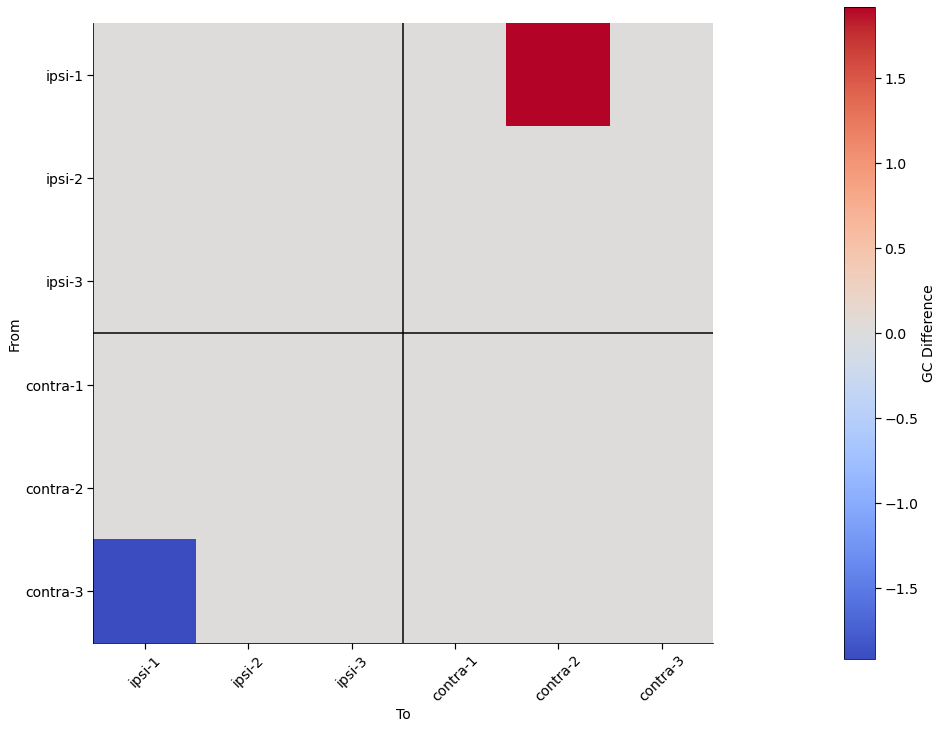

In [47]:
# Create a GridSpec for better layout control
fig = plt.figure(figsize=(14, 12))
gs = GridSpec(1, 2, width_ratios=[1, 0.05])

significant_diff_gc_matrix = copy.copy(observed_diff_gc)
significant_diff_gc_matrix[p_values_diff >= 0.05] = 0

# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))

# Plot the GC difference
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(significant_diff_gc_matrix, cmap='coolwarm', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')


# Add a single colorbar to the right
cbar_ax = fig.add_subplot(gs[0, 1])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('GC Difference', fontsize=14)

plt.subplots_adjust(wspace=0.4)
plt.show()


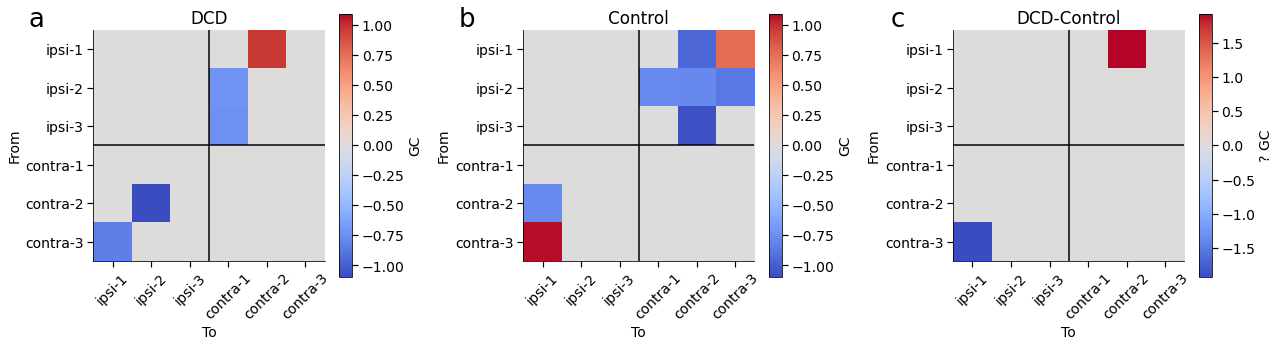

In [50]:
# Create a GridSpec for better layout control
fig = plt.figure(figsize=(6 * len(signed_gc_matrices)+6, 5))
gs = GridSpec(1, 3)

# Calculate a dynamic clim based on all conditions
all_gc_values = []
for cond in signed_gc_matrices:
    significant_gc_matrix = np.mean(np.array(signed_gc_matrices[cond]), axis=0)
    significant_gc_matrix[one_samp_p_values[cond] >= 0.05] = 0
    all_gc_values.extend(significant_gc_matrix.flatten())

common_clim = [-max(abs(np.min(all_gc_values)), np.max(all_gc_values)), max(abs(np.min(all_gc_values)), np.max(all_gc_values))]

ax = fig.add_subplot(gs[0, 0])
significant_gc_matrix = np.mean(np.array(signed_gc_matrices['dcd']), axis=0)
significant_gc_matrix[one_samp_p_values['dcd'] >= 0.05] = 0
# Display results
im = ax.imshow(significant_gc_matrix, cmap='coolwarm', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
ax.set_title('DCD')
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')
add_subplot_label(ax, 'a', y=1.1)


ax = fig.add_subplot(gs[0, 1])
significant_gc_matrix = np.mean(np.array(signed_gc_matrices['typ']), axis=0)
significant_gc_matrix[one_samp_p_values['typ'] >= 0.05] = 0
# Display results
im = ax.imshow(significant_gc_matrix, cmap='coolwarm', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
ax.set_title('Control')
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')
add_subplot_label(ax, 'b', y=1.1)
    
    
# Plot the GC difference
ax = fig.add_subplot(gs[0, 2])
significant_diff_gc_matrix = copy.copy(observed_diff_gc)
significant_diff_gc_matrix[p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='coolwarm', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
ax.set_title('DCD-Control')
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='? GC')
add_subplot_label(ax, 'c', y=1.1)

plt.tight_layout()

plt.savefig('./manuscript/figx_c3c4_burst_connectivity_ipsi_contra_pc6.pdf',dpi=600)